# **Load Dataset**

In [1]:
import pandas as pd
df=pd.read_csv("/content/headbrain.csv")
df.head()


FileNotFoundError: [Errno 2] No such file or directory: '/content/headbrain.csv'

In [ ]:
X=df['Head Size(cm^3)'].values
y=df['Brain Weight(grams)'].values

# **Calculate Parameter**

In [ ]:
import numpy as np
X_sum=np.sum(X)
X_squared_sum=np.sum(X*X)
n=len(X)
print("Sum of X: ",X_sum)
print("Sum of X squared:",X_squared_sum)
print("Length of X:",n)

# **Estimated Parameters**

In [ ]:
import numpy as np

n = len(X)

numer=n*np.sum(X*y)-np.sum(X)*np.sum(y)
denom=n*np.sum(X*X)-(np.sum(X))**2
w1=numer/denom

w0=(np.sum(y)-w1*(np.sum(X)))/n
w1,w0

# **Plot Regression Line**

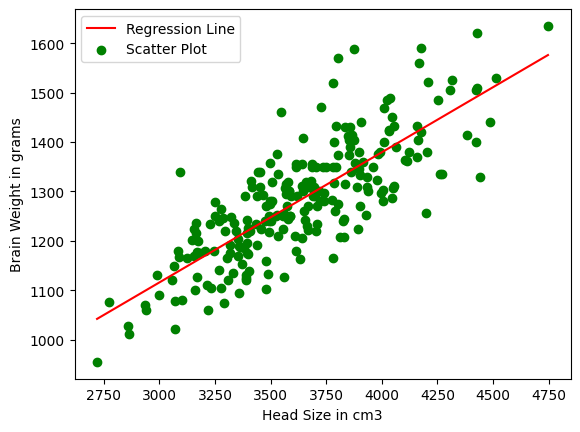

In [ ]:
import matplotlib.pyplot as plt
max_x=np.max(X)
min_x =np.min(X)

#Calculating line values x and y
x1=np.linspace(min_x, max_x)
y1=w0+w1*x1


plt.plot(x1, y1, color='red', label='Regression Line')


plt.scatter(X, y, c='green', label='Scatter Plot')
plt.xlabel('Head Size in cm3')
plt.ylabel('Brain Weight in grams')
plt.legend()
plt.show()

# **Calculate rmse**

In [ ]:
rmse=0
for i in range(n):
  y_pred=w0+w1*X[i]
  rmse+=(y[i]-y_pred)**2
rmse=np.sqrt(rmse/n)
print("RMSE=",rmse)


RMSE= 72.12062137837088


# **Calculate R2 score**

In [ ]:
ss_tot=0
ss_res=0


y_mean=np.mean(y)
for i in range(n):
  y_pred=w0+w1*X[i]
  ss_tot +=(y[i]-y_mean)**2
  ss_res +=(y[i]-y_pred)**2

r2=1-(ss_res/ss_tot)
print("R2 Score=",r2)

R2 Score= 0.6393117199570004


# **Uni variate regression**

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats
x=[5,7,8,7,2,17,2,9,4,11,12,9,6]
y=y = [99,86,87,88,111,86,103,87,94,78,77,85,86]

slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
   return slope * x + intercept

mymodel = list(map(myfunc, x))


R Squared Value: -0.758591524376155
std_err Value: 0.453536157607742


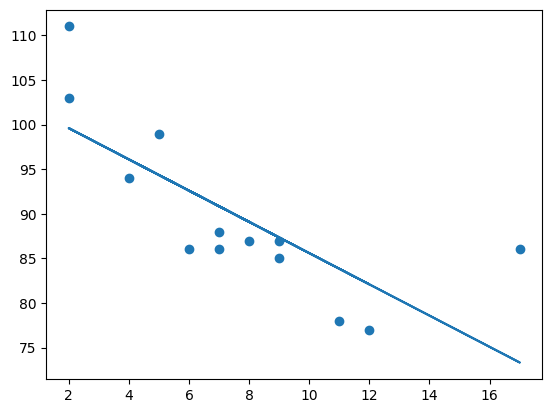

In [ ]:
plt.scatter(x, y)
plt.plot(x, mymodel)

print("R Squared Value:", r)

print("std_err Value:", std_err)

plt.show()


# **Activity 3**

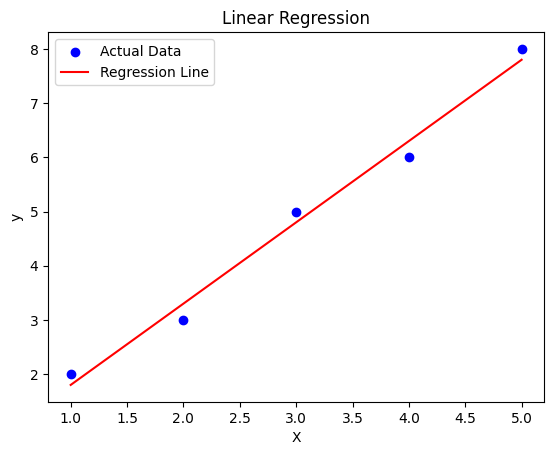

RMSE: 0.24494897427831783
R² Score: 0.9868421052631579


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 5, 6, 8])

# Calculate w1 (Slope) and w0 (Intercept)
n = len(X)
mean_x = np.mean(X)
mean_y = np.mean(y)

# Formula for slope w1 = Σ((x - mean_x) * (y - mean_y)) / Σ((x - mean_x)^2)
w1 = np.sum((X - mean_x) * (y - mean_y)) / np.sum((X - mean_x) ** 2)

# Formula for intercept w0 = mean_y - w1 * mean_x
w0 = mean_y - w1 * mean_x

# Predictions
y_pred = w0 + w1 * X

# Plot Data and Regression Line
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, y_pred, color="red", label="Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Linear Regression")
plt.show()

# RMSE Calculation
rmse = np.sqrt(np.mean((y - y_pred) ** 2))
print(f"RMSE: {rmse}")

# R2 Score Calculation
ss_total = np.sum((y - mean_y) ** 2)
ss_residual = np.sum((y - y_pred) ** 2)
r2_score = 1 - (ss_residual / ss_total)

print(f"R² Score: {r2_score}")


# **Data for regression**

Intercept: [4.01836279]
Slope: [[3.03215187]]


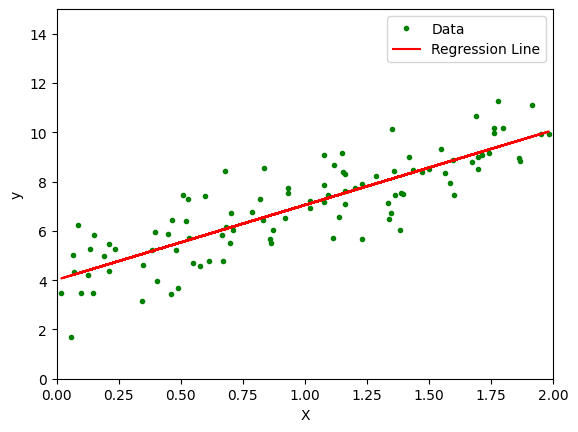

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
# Generate synthetic data
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)
# Fit a linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X, y)
# Print the intercept and slope
print("Intercept:", lin_reg.intercept_)
print("Slope:", lin_reg.coef_)
# Predict y values for the regression line
y_pred = lin_reg.predict(X)
# Plot the data and regression line
fig, ax = plt.subplots()
ax.set_xlabel('X')
ax.set_ylabel('y')  # Corrected quotation mark
ax.plot(X, y, "g.", label="Data")  # Scatter plot of the data
ax.plot(X, y_pred, "r-", label="Regression Line")  # Regression line
plt.axis([0, 2, 0, 15])
plt.legend()
plt.show()

# **Gradient Descent Implementation**

Final theta values:
[[4.16104533]
 [2.81783733]]


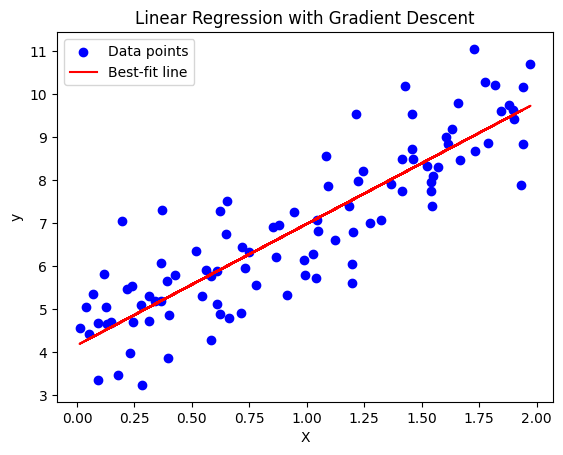

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
X = 2 * np.random.rand(100, 1)  # 100 random points between 0 and 2
y = 4 + 3 * X + np.random.randn(100, 1)  # y = 4 + 3x + noise


X_b = np.c_[np.ones((100, 1)), X]
# Hyperparameters
eta = 0.1  # Learning rate
n_iterations = 100  # Number of iterations
# Random initialization of theta
theta = np.random.randn(2, 1)
# Gradient Descent
for iteration in range(n_iterations):
   gradients = 2 / 100 * X_b.T.dot(X_b.dot(theta) - y)  # Compute gradients
   theta = theta - eta * gradients

print("Final theta values:")
print(theta)

# Plot the data and the best-fit line
plt.scatter(X, y, color="blue", label="Data points")
plt.plot(X, X_b.dot(theta), color="red", label="Best-fit line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Linear Regression with Gradient Descent")
plt.show()


# **Activity 2**

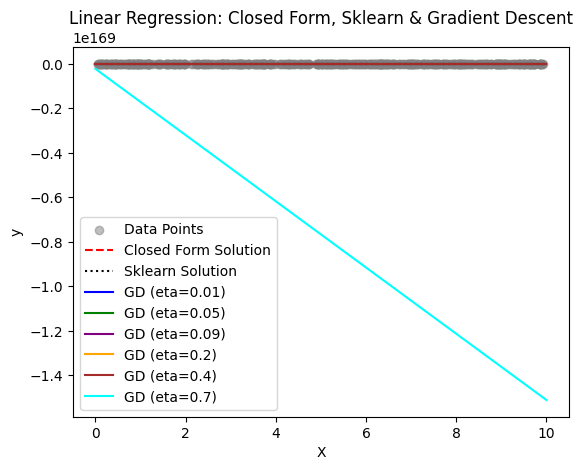

Closed-form Solution: w0 = 6.68, w1 = 4.07
Sklearn Solution: w0 = 6.68, w1 = 4.07
Gradient Descent (eta=0.01): w0 = 3.91, w1 = 4.48
Gradient Descent (eta=0.05): w0 = -654193789400289830212608641134430781440.00, w1 = -4395998936985492267729467715586535456768.00
Gradient Descent (eta=0.09): w0 = -267514510244366520877945693381062013321181183925912526885395839206817792.00, w1 = -1797622542000105087517227305079129681335948029679069506842203688276066304.00
Gradient Descent (eta=0.2): w0 = -384334473838083497012479524339264908823477815729540910640631411396577162087210200669533979942920041279095046144.00, w1 = -2582619960345269796872784448183899375335351109283846855609720438405141305864518795240715157303736326480644276224.00
Gradient Descent (eta=0.4): w0 = -20365348187041240739161529413898611851147580344776679737237941802941695138972807264198530493746444549421888954449077109805633417141467905785856.00, w1 = -136849432740171600477506498034186934846115218857497613562756274618708359459220820571

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Step 1: Generate synthetic dataset (y = 4x + 7 + noise)
np.random.seed(42)
X = 10 * np.random.rand(500, 1)  # Random X values between 0 and 10
y = 4 * X + 7 + np.random.randn(500, 1) * 3  # Adding some noise

# Step 2: Closed-form solution (Normal Equation)
X_b = np.c_[np.ones((500, 1)), X]  # Adding bias term (column of ones)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y  # (X^T * X)^-1 * X^T * y

w0_closed, w1_closed = theta_best.flatten()  # Extract w0 and w1

# Step 3: Using Sklearn's Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
w0_sklearn, w1_sklearn = lin_reg.intercept_[0], lin_reg.coef_[0][0]

# Step 4: Gradient Descent Implementation
def gradient_descent(X, y, eta, iterations=100):
    m = len(y)
    theta = np.random.randn(2, 1)  # Random initial weights
    X_b = np.c_[np.ones((m, 1)), X]  # Add bias term

    for i in range(iterations):
        gradients = 2/m * X_b.T @ (X_b @ theta - y)
        theta -= eta * gradients  # Update rule

    return theta.flatten()  # Return w0 and w1

# Learning rates to try
etas = [0.01, 0.05, 0.09, 0.2, 0.4, 0.7]
colors = ["blue", "green", "purple", "orange", "brown", "cyan"]

# Plot Original Data
plt.scatter(X, y, color="gray", alpha=0.5, label="Data Points")

# Plot Closed-form solution
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
y_closed = w0_closed + w1_closed * X_plot
plt.plot(X_plot, y_closed, color="red", linestyle="--", label="Closed Form Solution")

# Plot Sklearn solution
y_sklearn = w0_sklearn + w1_sklearn * X_plot
plt.plot(X_plot, y_sklearn, color="black", linestyle=":", label="Sklearn Solution")

# Apply Gradient Descent for each learning rate
for eta, color in zip(etas, colors):
    w0_gd, w1_gd = gradient_descent(X, y, eta)
    y_gd = w0_gd + w1_gd * X_plot
    plt.plot(X_plot, y_gd, color=color, label=f"GD (eta={eta})")

# Show final plot
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Linear Regression: Closed Form, Sklearn & Gradient Descent")
plt.show()

# Print Estimated Parameters
print(f"Closed-form Solution: w0 = {w0_closed:.2f}, w1 = {w1_closed:.2f}")
print(f"Sklearn Solution: w0 = {w0_sklearn:.2f}, w1 = {w1_sklearn:.2f}")
for eta in etas:
    w0_gd, w1_gd = gradient_descent(X, y, eta)
    print(f"Gradient Descent (eta={eta}): w0 = {w0_gd:.2f}, w1 = {w1_gd:.2f}")


# **Stochastic GD**

Final theta values:
[[4.33483995]
 [2.43658052]]


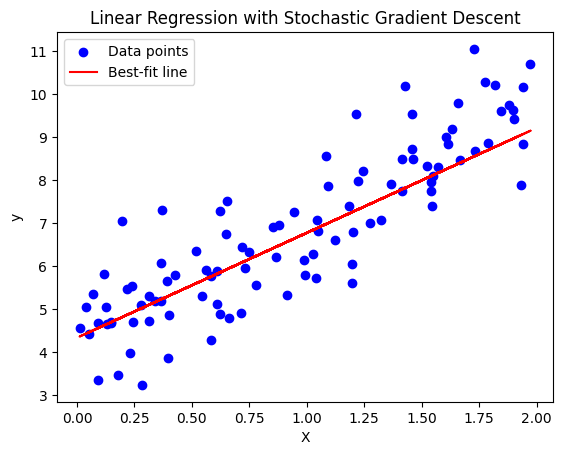

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate some sample data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)  # 100 random points between 0 and 2
y = 4 + 3 * X + np.random.randn(100, 1)  # y = 4 + 3x + noise
# Add a column of ones to X for the bias term (theta_0)
X_b = np.c_[np.ones((100, 1)), X]
# Hyperparameters
eta = 0.1  # Learning rate
n_epochs = 50  # Number of passes over the dataset
# Random initialization of theta
theta = np.random.randn(2, 1)
# Stochastic Gradient Descent
for epoch in range(n_epochs):
  for i in range(len(X_b)):  # Iterate over each training example
        random_index = np.random.randint(len(X_b))  # Pick a random example
        xi = X_b[random_index:random_index+1]  # Get one random example
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        theta = theta - eta * gradients

print("Final theta values:")
print(theta)
# Plot the data and the best-fit line
plt.scatter(X, y, color="blue", label="Data points")
plt.plot(X, X_b.dot(theta), color="red", label="Best-fit line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Linear Regression with Stochastic Gradient Descent")
plt.show()